In [1]:
import numpy as np
import math
import random
from collections import namedtuple
import heapq
import warnings
import time

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ==================== 数据结构定义 ====================
Node = namedtuple('Node', ['x', 'y', 'demand'])

class Zone:
    """禁飞区：任意多边形（凸或凹），用顶点列表表示"""
    def __init__(self, vertices, active_start, active_end):
        self.vertices = vertices
        self.active_start = active_start
        self.active_end = active_end
        self.min_x = min(v[0] for v in vertices)
        self.max_x = max(v[0] for v in vertices)
        self.min_y = min(v[1] for v in vertices)
        self.max_y = max(v[1] for v in vertices)
    
    def contains(self, x, y, time):
        if not (self.active_start <= time <= self.active_end):
            return False
        if not (self.min_x <= x <= self.max_x and self.min_y <= y <= self.max_y):
            return False
        inside = False
        n = len(self.vertices)
        for i in range(n):
            x1, y1 = self.vertices[i]
            x2, y2 = self.vertices[(i + 1) % n]
            if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
                inside = not inside
        return inside
    
    def line_intersects(self, x1, y1, x2, y2, time):
        if not (self.active_start <= time <= self.active_end):
            return False
        if self.contains(x1, y1, time) or self.contains(x2, y2, time):
            return True
        n = len(self.vertices)
        for i in range(n):
            x3, y3 = self.vertices[i]
            x4, y4 = self.vertices[(i + 1) % n]
            if self._segments_intersect(x1, y1, x2, y2, x3, y3, x4, y4):
                return True
        return False
    
    def _segments_intersect(self, x1, y1, x2, y2, x3, y3, x4, y4):
        def orientation(ax, ay, bx, by, cx, cy):
            return (bx - ax) * (cy - ay) - (by - ay) * (cx - ax)
        def on_segment(ax, ay, bx, by, cx, cy):
            return (min(ax, bx) <= cx <= max(ax, bx) and min(ay, by) <= cy <= max(ay, by))
        
        o1 = orientation(x1, y1, x2, y2, x3, y3)
        o2 = orientation(x1, y1, x2, y2, x4, y4)
        o3 = orientation(x3, y3, x4, y4, x1, y1)
        o4 = orientation(x3, y3, x4, y4, x2, y2)
        
        if o1 * o2 < 0 and o3 * o4 < 0:
            return True
        if o1 == 0 and on_segment(x1, y1, x2, y2, x3, y3):
            return True
        if o2 == 0 and on_segment(x1, y1, x2, y2, x4, y4):
            return True
        if o3 == 0 and on_segment(x3, y3, x4, y4, x1, y1):
            return True
        if o4 == 0 and on_segment(x3, y3, x4, y4, x2, y2):
            return True
        return False

Problem = namedtuple('Problem', [
    'nodes', 'truck_speed', 'drone_speed', 'truck_capacity', 'drone_capacity',
    'truck_max_dist', 'drone_max_dist', 'num_trucks', 'truck_feasible', 'no_fly_zones'
])

# ==================== 工具函数 ====================
def euclidean_distance(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

def build_distance_matrix(nodes):
    n = len(nodes)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist[i, j] = euclidean_distance(nodes[i], nodes[j])
    return dist

# ==================== 动态无人机距离函数 ====================
def build_drone_distance_function(nodes, zones):
    cache = {}
    
    def get_distance(i, j, current_time):
        if i == j:
            return 0.0
        if math.isinf(current_time):
            return float('inf')
        time_key = int(current_time)
        key = (i, j, time_key)
        if key in cache:
            return cache[key]

        x1, y1 = nodes[i].x, nodes[i].y
        x2, y2 = nodes[j].x, nodes[j].y

        need_detour = False
        for zone in zones:
            if zone.line_intersects(x1, y1, x2, y2, current_time):
                need_detour = True
                break

        if not need_detour:
            dist = math.hypot(x2 - x1, y2 - y1)
            cache[key] = dist
            return dist
        else:
            all_x = [node.x for node in nodes]
            all_y = [node.y for node in nodes]
            for zone in zones:
                for vx, vy in zone.vertices:
                    all_x.append(vx)
                    all_y.append(vy)
            
            margin = 20
            min_x = min(all_x) - margin
            max_x = max(all_x) + margin
            min_y = min(all_y) - margin
            max_y = max(all_y) + margin
            grid_res = 2.0

            def to_grid(x, y):
                return int(round((x - min_x) / grid_res)), int(round((y - min_y) / grid_res))

            start_gx, start_gy = to_grid(x1, y1)
            goal_gx, goal_gy = to_grid(x2, y2)

            if any(zone.contains(x1, y1, current_time) for zone in zones) or \
               any(zone.contains(x2, y2, current_time) for zone in zones):
                cache[key] = float('inf')
                return float('inf')

            directions = [(1, 0, grid_res), (-1, 0, grid_res), (0, 1, grid_res), (0, -1, grid_res),
                         (1, 1, math.sqrt(2)*grid_res), (1, -1, math.sqrt(2)*grid_res),
                         (-1, 1, math.sqrt(2)*grid_res), (-1, -1, math.sqrt(2)*grid_res)]

            def heuristic(gx, gy):
                dx = (gx - goal_gx) * grid_res
                dy = (gy - goal_gy) * grid_res
                return math.hypot(dx, dy)

            def is_blocked(gx, gy):
                x = min_x + gx * grid_res + grid_res/2
                y = min_y + gy * grid_res + grid_res/2
                return any(zone.contains(x, y, current_time) for zone in zones)

            open_set = []
            heapq.heappush(open_set, (0, start_gx, start_gy))
            g_score = {(start_gx, start_gy): 0}
            closed_set = set()

            while open_set:
                _, gx, gy = heapq.heappop(open_set)
                if (gx, gy) in closed_set:
                    continue
                if (gx, gy) == (goal_gx, goal_gy):
                    dist = g_score[(gx, gy)]
                    cache[key] = dist
                    return dist
                closed_set.add((gx, gy))
                for dx, dy, cost in directions:
                    ngx, ngy = gx + dx, gy + dy
                    if ngx < 0 or ngy < 0:
                        continue
                    if ngx * grid_res > (max_x - min_x) or ngy * grid_res > (max_y - min_y):
                        continue
                    if is_blocked(ngx, ngy):
                        continue
                    tentative_g = g_score[(gx, gy)] + cost
                    if (ngx, ngy) not in g_score or tentative_g < g_score[(ngx, ngy)]:
                        g_score[(ngx, ngy)] = tentative_g
                        heapq.heappush(open_set, (tentative_g + heuristic(ngx, ngy), ngx, ngy))
            
            cache[key] = float('inf')
            return float('inf')
    
    return get_distance

# ==================== 无人机任务可行性检查 ====================
def check_drone_mission_feasibility(launch_idx, cust_idx, rendezvous_idx, prob, drone_dist_func, current_time):
    if prob.nodes[cust_idx].demand > prob.drone_capacity:
        return False
    d1 = drone_dist_func(launch_idx, cust_idx, current_time)
    if d1 == float('inf'):
        return False
    d2 = drone_dist_func(cust_idx, rendezvous_idx, current_time + d1 / prob.drone_speed)
    if d2 == float('inf'):
        return False
    if d1 + d2 > prob.drone_max_dist:
        return False
    return True

# ==================== 初始解生成 ====================
def initial_solution(prob, dist):
    n_customers = len(prob.nodes) - 1
    customers = list(range(1, n_customers + 1))
    random.shuffle(customers)
    routes = []

    for cust in customers:
        inserted = False
        for r_idx, route in enumerate(routes):
            current_demand = sum(prob.nodes[node].demand for node in route if node != 0)
            if current_demand + prob.nodes[cust].demand > prob.truck_capacity:
                continue
            for pos in range(1, len(route)):
                new_route = route[:pos] + [cust] + route[pos:]
                feasible = True
                new_dist = 0
                for i in range(len(new_route) - 1):
                    u, v = new_route[i], new_route[i + 1]
                    if not prob.truck_feasible[u, v]:
                        feasible = False
                        break
                    new_dist += dist[u, v]
                if not feasible:
                    continue
                if new_dist > prob.truck_max_dist:
                    continue
                route[:] = new_route
                inserted = True
                break
            if inserted:
                break
        if not inserted:
            new_route = [0, cust, 0]
            routes.append(new_route)
    return {i: routes[i] for i in range(len(routes))}

# ==================== 无人机路径优化 ====================
def optimize_drone_route(truck_route, prob, dist, drone_dist_func, current_time=0):
    n = len(truck_route)
    graph = [[] for _ in range(n + 1)]

    for i in range(n - 1):
        u_node = truck_route[i]
        v_node = truck_route[i + 1]
        if prob.truck_feasible[u_node, v_node]:
            truck_time = dist[u_node, v_node] / prob.truck_speed
            graph[i].append((i + 1, truck_time, None))

    for i in range(n - 2):
        u_node = truck_route[i]
        j = i + 2
        v_node = truck_route[j]
        k_node = truck_route[i + 1]
        
        mission_time_est = current_time
        for idx in range(i):
            mission_time_est += dist[truck_route[idx], truck_route[idx+1]] / prob.truck_speed
        
        if not check_drone_mission_feasibility(u_node, k_node, v_node, prob, drone_dist_func, mission_time_est):
            continue
        
        d1 = drone_dist_func(u_node, k_node, mission_time_est)
        d2 = drone_dist_func(k_node, v_node, mission_time_est + d1 / prob.drone_speed)
        drone_time = (d1 + d2) / prob.drone_speed
        truck_time = dist[u_node, v_node] / prob.truck_speed
        weight = max(truck_time, drone_time)
        edge_info = (i, u_node, k_node, v_node, drone_time, truck_time)
        graph[i].append((j, weight, edge_info))

    graph[n-1].append((n, 0, None))

    start = 0
    dist_arr = [math.inf] * (n + 1)
    dist_arr[start] = current_time
    prev_node = [None] * (n + 1)
    prev_edge = [None] * (n + 1)
    pq = [(current_time, start)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist_arr[u]:
            continue
        for v, w, info in graph[u]:
            nd = d + w
            if nd < dist_arr[v]:
                dist_arr[v] = nd
                prev_node[v] = u
                prev_edge[v] = info
                heapq.heappush(pq, (nd, v))

    path_indices = []
    cur = n
    while cur is not None:
        path_indices.append(cur)
        cur = prev_node[cur]
    path_indices.reverse()

    truck_actual = [truck_route[idx] for idx in path_indices if idx < n]
    drone_assignments = []
    drone_takeoff_times = []
    wait_drone_total = 0.0
    wait_truck_total = 0.0

    for i in range(len(path_indices) - 1):
        v_idx = path_indices[i + 1]
        info = prev_edge[v_idx]
        if info is not None:
            pos_i, u_node, k_node, v_node, drone_time, truck_time = info
            drone_assignments.append((u_node, k_node, v_node))
            drone_takeoff_times.append(dist_arr[pos_i])
            if drone_time > truck_time:
                wait_drone_total += drone_time - truck_time
            else:
                wait_truck_total += truck_time - drone_time

    completion_time = dist_arr[n]
    
    truck_dist = 0.0
    for i in range(len(truck_actual) - 1):
        truck_dist += dist[truck_actual[i]][truck_actual[i + 1]]
    
    drone_dist = 0.0
    for idx, (launch, cust, rendezvous) in enumerate(drone_assignments):
        takeoff_time = drone_takeoff_times[idx]
        d1 = drone_dist_func(launch, cust, takeoff_time)
        d2 = drone_dist_func(cust, rendezvous, takeoff_time + d1 / prob.drone_speed)
        drone_dist += d1 + d2

    return truck_actual, drone_assignments, completion_time, truck_dist, drone_dist, wait_drone_total, wait_truck_total

# ==================== 邻域算子（保留原有小范围算子）====================
def _is_route_feasible(route, prob, dist):
    demand = sum(prob.nodes[node].demand for node in route if node != 0)
    if demand > prob.truck_capacity:
        return False
    total_dist = 0
    for i in range(len(route) - 1):
        u, v = route[i], route[i + 1]
        if not prob.truck_feasible[u, v]:
            return False
        total_dist += dist[u, v]
    if total_dist > prob.truck_max_dist:
        return False
    return True

def operator_relocate(solution, prob, dist, drone_dist_func):
    truck_ids = list(solution.keys())
    if len(truck_ids) < 2:
        return None
    
    src_id = random.choice(truck_ids)
    tgt_id = random.choice([tid for tid in truck_ids if tid != src_id])
    src_route = solution[src_id][:]
    tgt_route = solution[tgt_id][:]
    
    movable = [i for i in range(1, len(src_route)-1)]
    if not movable:
        return None
    
    cust_idx = random.choice(movable)
    customer = src_route[cust_idx]
    
    new_src = src_route[:cust_idx] + src_route[cust_idx+1:]
    if not _is_route_feasible(new_src, prob, dist):
        return None
    
    for pos in range(1, len(tgt_route)):
        new_tgt = tgt_route[:pos] + [customer] + tgt_route[pos:]
        if _is_route_feasible(new_tgt, prob, dist):
            new_solution = solution.copy()
            new_solution[src_id] = new_src
            new_solution[tgt_id] = new_tgt
            return new_solution, ('relocate', src_id, tgt_id, customer)
    return None

def operator_exchange(solution, prob, dist, drone_dist_func):
    truck_ids = list(solution.keys())
    if len(truck_ids) < 2:
        return None
    
    id1, id2 = random.sample(truck_ids, 2)
    route1 = solution[id1][:]
    route2 = solution[id2][:]
    
    idx1_options = [i for i in range(1, len(route1)-1)]
    idx2_options = [i for i in range(1, len(route2)-1)]
    
    if not idx1_options or not idx2_options:
        return None
    
    idx1 = random.choice(idx1_options)
    idx2 = random.choice(idx2_options)
    
    cust1 = route1[idx1]
    cust2 = route2[idx2]
    
    new_route1 = route1[:idx1] + [cust2] + route1[idx1+1:]
    new_route2 = route2[:idx2] + [cust1] + route2[idx2+1:]
    
    if _is_route_feasible(new_route1, prob, dist) and _is_route_feasible(new_route2, prob, dist):
        new_solution = solution.copy()
        new_solution[id1] = new_route1
        new_solution[id2] = new_route2
        return new_solution, ('exchange', id1, id2, cust1, cust2)
    return None

def operator_2opt(solution, prob, dist, drone_dist_func):
    truck_ids = list(solution.keys())
    if not truck_ids:
        return None
    src_id = random.choice(truck_ids)
    route = solution[src_id]
    inner_indices = list(range(1, len(route) - 1))
    if len(inner_indices) < 2:
        return None
    l = random.choice(inner_indices)
    r = random.choice(inner_indices)
    if l > r:
        l, r = r, l
    new_route = route[:l] + route[l:r+1][::-1] + route[r+1:]
    if not _is_route_feasible(new_route, prob, dist):
        return None
    new_solution = solution.copy()
    new_solution[src_id] = new_route
    return new_solution, ('2opt', src_id, (l, r))

def operator_cross(solution, prob, dist, drone_dist_func):
    truck_ids = list(solution.keys())
    if len(truck_ids) < 2:
        return None
    
    id1, id2 = random.sample(truck_ids, 2)
    route1 = solution[id1][:]
    route2 = solution[id2][:]
    
    if len(route1) < 3 or len(route2) < 3:
        return None
    
    cross1 = random.randint(1, len(route1)-2)
    cross2 = random.randint(1, len(route2)-2)
    
    new_route1 = route1[:cross1] + route2[cross2:]
    new_route2 = route2[:cross2] + route1[cross1:]
    
    if _is_route_feasible(new_route1, prob, dist) and _is_route_feasible(new_route2, prob, dist):
        new_solution = solution.copy()
        new_solution[id1] = new_route1
        new_solution[id2] = new_route2
        return new_solution, ('cross', id1, id2, cross1, cross2)
    return None

# ==================== 新增：大规模破坏-修复算子（ALNS风格）====================

def destroy_random_remove(solution, prob, remove_ratio=0.2):
    """随机移除一定比例的客户"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    removed = []
    
    all_customers = []
    for tid, route in new_solution.items():
        all_customers.extend([(tid, idx, node) for idx, node in enumerate(route) if node != 0])
    
    if not all_customers:
        return solution, removed
    
    n_remove = max(1, int(len(all_customers) * remove_ratio))
    to_remove = random.sample(all_customers, min(n_remove, len(all_customers)))
    
    for tid, idx, cust in sorted(to_remove, key=lambda x: x[1], reverse=True):
        route = new_solution[tid]
        if idx < len(route) - 1:
            route.pop(idx)
            removed.append(cust)
    
    empty_tids = [tid for tid, route in new_solution.items() if len(route) <= 2]
    for tid in empty_tids:
        del new_solution[tid]
    
    return new_solution, removed


def destroy_worst_remove(solution, prob, remove_ratio=0.2, dist=None):
    """移除成本贡献最大的客户"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    
    customer_savings = []
    for tid, route in new_solution.items():
        if len(route) <= 2:
            continue
        
        orig_cost = 0
        for i in range(len(route) - 1):
            u, v = route[i], route[i + 1]
            orig_cost += dist[u, v]
        
        for idx, cust in enumerate(route):
            if cust == 0:
                continue
            new_route = route[:idx] + route[idx+1:]
            if len(new_route) <= 2:
                new_cost = 0
            else:
                new_cost = 0
                for i in range(len(new_route) - 1):
                    u, v = new_route[i], new_route[i + 1]
                    new_cost += dist[u, v]
            saving = orig_cost - new_cost
            if saving > 0:
                customer_savings.append((cust, tid, idx, saving))
    
    customer_savings.sort(key=lambda x: x[3], reverse=True)
    n_remove = max(1, int(len([c for c in new_solution.values() if len(c) > 2]) * remove_ratio))
    to_remove = customer_savings[:n_remove]
    
    removed = []
    for cust, tid, idx, _ in to_remove:
        route = new_solution[tid]
        if idx < len(route) and route[idx] == cust:
            route.pop(idx)
            removed.append(cust)
    
    empty_tids = [tid for tid, route in new_solution.items() if len(route) <= 2]
    for tid in empty_tids:
        del new_solution[tid]
    
    return new_solution, removed


def destroy_shaw_remove(solution, prob, remove_ratio=0.2, dist=None):
    """移除相似度高的客户（Shaw移除）"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    
    all_customers = []
    cust_info = []
    for tid, route in new_solution.items():
        for cust in route:
            if cust == 0:
                continue
            all_customers.append((tid, cust))
            cust_info.append((tid, cust, prob.nodes[cust].x, prob.nodes[cust].y))
    
    if len(all_customers) <= 1:
        return solution, []
    
    first = random.choice(all_customers)
    removed = [first]
    remaining = [c for c in all_customers if c != first]
    
    n_remove = max(1, int(len(all_customers) * remove_ratio))
    
    while len(removed) < n_remove and remaining:
        last_tid, last_cust = removed[-1]
        last_x, last_y = prob.nodes[last_cust].x, prob.nodes[last_cust].y
        
        best_idx = -1
        best_sim = float('inf')
        for i, (tid, cust) in enumerate(remaining):
            x, y = prob.nodes[cust].x, prob.nodes[cust].y
            sim = math.hypot(x - last_x, y - last_y)
            if sim < best_sim:
                best_sim = sim
                best_idx = i
        
        removed.append(remaining.pop(best_idx))
    
    removed_custs = [cust for _, cust in removed]
    
    for tid, cust in removed:
        route = new_solution[tid]
        if cust in route:
            idx = route.index(cust)
            route.pop(idx)
    
    empty_tids = [tid for tid, route in new_solution.items() if len(route) <= 2]
    for tid in empty_tids:
        del new_solution[tid]
    
    return new_solution, removed_custs


def destroy_route_remove(solution, prob, remove_ratio=0.2):
    """移除整条路径"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    
    if len(new_solution) <= 1:
        return solution, []
    
    n_remove_routes = max(1, int(len(new_solution) * remove_ratio))
    to_remove_tids = random.sample(list(new_solution.keys()), min(n_remove_routes, len(new_solution)))
    
    removed = []
    for tid in to_remove_tids:
        route = new_solution[tid]
        for cust in route:
            if cust != 0:
                removed.append(cust)
        del new_solution[tid]
    
    return new_solution, removed


def repair_greedy_insert(solution, removed, prob, dist):
    """贪心插入修复"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    
    random.shuffle(removed)
    
    for cust in removed:
        best_tid = None
        best_pos = None
        best_cost = float('inf')
        
        for tid, route in new_solution.items():
            current_demand = sum(prob.nodes[node].demand for node in route if node != 0)
            if current_demand + prob.nodes[cust].demand > prob.truck_capacity:
                continue
            
            for pos in range(1, len(route)):
                new_route = route[:pos] + [cust] + route[pos:]
                feasible = True
                new_dist = 0
                for i in range(len(new_route) - 1):
                    u, v = new_route[i], new_route[i + 1]
                    if not prob.truck_feasible[u, v]:
                        feasible = False
                        break
                    new_dist += dist[u, v]
                if feasible and new_dist <= prob.truck_max_dist:
                    if new_dist < best_cost:
                        best_cost = new_dist
                        best_tid = tid
                        best_pos = pos
        
        if best_tid is not None:
            new_solution[best_tid].insert(best_pos, cust)
        else:
            new_key = max(new_solution.keys()) + 1 if new_solution else 0
            new_solution[new_key] = [0, cust, 0]
    
    return new_solution


def repair_regret_insert(solution, removed, prob, dist, k=2):
    """后悔值插入修复"""
    new_solution = {tid: route[:] for tid, route in solution.items()}
    remaining = list(removed)
    
    while remaining:
        best_cust = None
        best_insertion = None
        best_regret = -float('inf')
        
        for cust in remaining:
            insertions = []
            for tid, route in new_solution.items():
                current_demand = sum(prob.nodes[node].demand for node in route if node != 0)
                if current_demand + prob.nodes[cust].demand > prob.truck_capacity:
                    continue
                for pos in range(1, len(route)):
                    new_route = route[:pos] + [cust] + route[pos:]
                    feasible = True
                    new_dist = 0
                    for i in range(len(new_route) - 1):
                        u, v = new_route[i], new_route[i + 1]
                        if not prob.truck_feasible[u, v]:
                            feasible = False
                            break
                        new_dist += dist[u, v]
                    if feasible and new_dist <= prob.truck_max_dist:
                        insertions.append((tid, pos, new_dist))
            
            if not insertions:
                new_key = max(new_solution.keys()) + 1 if new_solution else 0
                insertions.append((new_key, 1, dist[0, cust] + dist[cust, 0]))
            
            insertions.sort(key=lambda x: x[2])
            
            if len(insertions) >= k:
                regret = insertions[k-1][2] - insertions[0][2]
            else:
                regret = insertions[-1][2] if insertions else 0
            
            if regret > best_regret:
                best_regret = regret
                best_cust = cust
                best_insertion = insertions[0]
        
        if best_cust is not None and best_insertion is not None:
            tid, pos, _ = best_insertion
            if tid in new_solution:
                new_solution[tid].insert(pos, best_cust)
            else:
                new_solution[tid] = [0, best_cust, 0]
            remaining.remove(best_cust)
        else:
            break
    
    return new_solution

# ==================== 改进的TS-SA主体（融合ALNS风格）====================
class ImprovedTS_ALNS:
    def __init__(self, prob, dist, drone_dist_func, max_iter=2000, tabu_len=15, patience=200,
                 c_truck_km=1.0, c_drone_km=0.1, c_truck_fixed=200, c_drone_fixed=10,
                 c_wait_drone=1.0, c_wait_truck=2.0,
                 temperature=2000, cooling_rate=0.98,
                 large_destroy_prob=0.3):  # 30%概率执行大规模破坏-修复
        
        self.prob = prob
        self.dist = dist
        self.drone_dist_func = drone_dist_func
        self.max_iter = max_iter
        self.tabu_len = tabu_len
        self.patience = patience
        self.tabu_list = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.iter_count = 0

        self.c_truck_km = c_truck_km
        self.c_drone_km = c_drone_km
        self.c_truck_fixed = c_truck_fixed
        self.c_drone_fixed = c_drone_fixed
        self.c_wait_drone = c_wait_drone
        self.c_wait_truck = c_wait_truck
        
        self.temperature = temperature
        self.cooling_rate = cooling_rate
        self.large_destroy_prob = large_destroy_prob
        
        # 大规模破坏-修复算子权重（自适应）
        self.destroy_operators = [
            ('random', lambda sol, ratio: destroy_random_remove(sol, prob, ratio)),
            ('worst', lambda sol, ratio: destroy_worst_remove(sol, prob, ratio, dist)),
            ('shaw', lambda sol, ratio: destroy_shaw_remove(sol, prob, ratio, dist)),
            ('route', lambda sol, ratio: destroy_route_remove(sol, prob, ratio))
        ]
        self.destroy_weights = [1.0, 1.0, 1.0, 0.5]
        self.destroy_scores = [0.0, 0.0, 0.0, 0.0]
        self.destroy_attempts = [0, 0, 0, 0]
        
        self.repair_operators = [
            ('greedy', lambda sol, rem: repair_greedy_insert(sol, rem, prob, dist)),
            ('regret', lambda sol, rem: repair_regret_insert(sol, rem, prob, dist, k=2))
        ]
        self.repair_weights = [1.0, 1.0]
        self.repair_scores = [0.0, 0.0]
        self.repair_attempts = [0, 0]
        
        # 小范围邻域算子（原有）
        self.local_operators = [
            ('relocate', operator_relocate),
            ('exchange', operator_exchange),
            ('2opt', operator_2opt),
            ('cross', operator_cross)
        ]
        self.local_weights = [1.0, 1.0, 0.5, 0.5]
        self.local_scores = [0.0, 0.0, 0.0, 0.0]
        self.local_attempts = [0, 0, 0, 0]
        
        self.remove_ratios = [0.1, 0.2, 0.3, 0.4]
        self.segment_size = 100
        self.reaction_factor = 0.5

    def evaluate(self, solution):
        total_truck_dist = 0.0
        total_drone_dist = 0.0
        total_wait_drone = 0.0
        total_wait_truck = 0.0
        total_drone_missions = 0

        for route in solution.values():
            if len(route) < 2:
                continue
            _, drone_assignments, _, truck_dist, drone_dist, wait_drone, wait_truck = optimize_drone_route(
                route, self.prob, self.dist, self.drone_dist_func)
            total_truck_dist += truck_dist
            total_drone_dist += drone_dist
            total_wait_drone += wait_drone
            total_wait_truck += wait_truck
            total_drone_missions += len(drone_assignments)

        num_trucks = len(solution)
        cost = (self.c_truck_km * total_truck_dist +
                self.c_drone_km * total_drone_dist +
                self.c_truck_fixed * num_trucks +
                self.c_drone_fixed * total_drone_missions +
                self.c_wait_drone * total_wait_drone +
                self.c_wait_truck * total_wait_truck)
        return cost

    def select_operator(self, weights):
        total = sum(weights)
        r = random.random() * total
        cumsum = 0
        for i, w in enumerate(weights):
            cumsum += w
            if r <= cumsum:
                return i
        return 0

    def apply_large_destroy_repair(self, solution, remove_ratio):
        """应用大规模破坏-修复"""
        # 选择破坏算子
        destroy_idx = self.select_operator(self.destroy_weights)
        self.destroy_attempts[destroy_idx] += 1
        destroy_op = self.destroy_operators[destroy_idx][1]
        
        destroyed, removed = destroy_op(solution, remove_ratio)
        
        if not removed or not destroyed:
            return solution, None, None, None, False
        
        # 选择修复算子
        repair_idx = self.select_operator(self.repair_weights)
        self.repair_attempts[repair_idx] += 1
        repair_op = self.repair_operators[repair_idx][1]
        
        new_solution = repair_op(destroyed, removed)
        
        return new_solution, destroy_idx, repair_idx, removed, True

    def apply_local_operator(self, solution):
        """应用小范围邻域算子"""
        op_idx = self.select_operator(self.local_weights)
        self.local_attempts[op_idx] += 1
        op_name, op_func = self.local_operators[op_idx]
        
        result = op_func(solution, self.prob, self.dist, self.drone_dist_func)
        if result:
            new_sol, info = result
            return new_sol, info, op_idx, True
        return solution, None, op_idx, False

    def update_scores(self, destroy_idx, repair_idx, local_idx, improved, is_new_best):
        """更新算子得分"""
        if destroy_idx is not None:
            if is_new_best:
                self.destroy_scores[destroy_idx] += 1.5
            elif improved:
                self.destroy_scores[destroy_idx] += 1.0
            else:
                self.destroy_scores[destroy_idx] += 0.5
        
        if repair_idx is not None:
            if is_new_best:
                self.repair_scores[repair_idx] += 1.5
            elif improved:
                self.repair_scores[repair_idx] += 1.0
            else:
                self.repair_scores[repair_idx] += 0.5
        
        if local_idx is not None:
            if is_new_best:
                self.local_scores[local_idx] += 1.5
            elif improved:
                self.local_scores[local_idx] += 1.0
            else:
                self.local_scores[local_idx] += 0.5

    def update_weights(self):
        """更新所有算子权重"""
        for i in range(len(self.destroy_weights)):
            if self.destroy_attempts[i] > 0:
                avg_score = self.destroy_scores[i] / self.destroy_attempts[i]
                self.destroy_weights[i] = self.destroy_weights[i] * (1 - self.reaction_factor) + \
                                          self.reaction_factor * avg_score
                self.destroy_weights[i] = max(0.1, min(3.0, self.destroy_weights[i]))
        
        for i in range(len(self.repair_weights)):
            if self.repair_attempts[i] > 0:
                avg_score = self.repair_scores[i] / self.repair_attempts[i]
                self.repair_weights[i] = self.repair_weights[i] * (1 - self.reaction_factor) + \
                                         self.reaction_factor * avg_score
                self.repair_weights[i] = max(0.1, min(3.0, self.repair_weights[i]))
        
        for i in range(len(self.local_weights)):
            if self.local_attempts[i] > 0:
                avg_score = self.local_scores[i] / self.local_attempts[i]
                self.local_weights[i] = self.local_weights[i] * (1 - self.reaction_factor) + \
                                        self.reaction_factor * avg_score
                self.local_weights[i] = max(0.1, min(3.0, self.local_weights[i]))
        
        self.destroy_scores = [0.0] * len(self.destroy_weights)
        self.destroy_attempts = [0] * len(self.destroy_weights)
        self.repair_scores = [0.0] * len(self.repair_weights)
        self.repair_attempts = [0] * len(self.repair_weights)
        self.local_scores = [0.0] * len(self.local_weights)
        self.local_attempts = [0] * len(self.local_weights)

    def is_tabu(self, op_info):
        if op_info is None:
            return False
        for tabu_obj, expire in self.tabu_list:
            if tabu_obj == op_info and expire > self.iter_count:
                return True
        return False

    def add_tabu(self, op_info):
        if op_info is None:
            return
        expire = self.iter_count + self.tabu_len
        self.tabu_list.append((op_info, expire))
        self.tabu_list = [(o, e) for (o, e) in self.tabu_list if e > self.iter_count]

    def search(self):
        """主搜索过程"""
        current = initial_solution(self.prob, self.dist)
        current_cost = self.evaluate(current)
        self.best_solution = current
        self.best_cost = current_cost

        print("\n=== 初始解 ===")
        for tid, route in current.items():
            print(f"卡车{tid+1}: {route}")
        print(f"初始总成本: {current_cost:.2f}\n")

        no_improve = 0
        
        # 阶段统计
        destroy_scores_seg = [0.0] * len(self.destroy_weights)
        destroy_attempts_seg = [0] * len(self.destroy_weights)
        repair_scores_seg = [0.0] * len(self.repair_weights)
        repair_attempts_seg = [0] * len(self.repair_weights)
        local_scores_seg = [0.0] * len(self.local_weights)
        local_attempts_seg = [0] * len(self.local_weights)

        for self.iter_count in range(self.max_iter):
            # 每50次迭代更新权重
            if self.iter_count > 0 and self.iter_count % self.segment_size == 0:
                self.update_weights()
                destroy_scores_seg = [0.0] * len(self.destroy_weights)
                destroy_attempts_seg = [0] * len(self.destroy_weights)
                repair_scores_seg = [0.0] * len(self.repair_weights)
                repair_attempts_seg = [0] * len(self.repair_weights)
                local_scores_seg = [0.0] * len(self.local_weights)
                local_attempts_seg = [0] * len(self.local_weights)

            # 决定使用大规模破坏-修复还是小范围邻域搜索
            use_large = random.random() < self.large_destroy_prob
            
            if use_large:
                # 大规模破坏-修复
                remove_ratio = random.choice(self.remove_ratios)
                new_sol, destroy_idx, repair_idx, removed, success = self.apply_large_destroy_repair(current, remove_ratio)
                
                if not success or not new_sol:
                    continue
                
                new_cost = self.evaluate(new_sol)
                
                # 更新阶段统计
                if destroy_idx is not None:
                    destroy_attempts_seg[destroy_idx] += 1
                if repair_idx is not None:
                    repair_attempts_seg[repair_idx] += 1
                
                improved = new_cost < current_cost
                is_new_best = new_cost < self.best_cost
                
                if is_new_best:
                    destroy_scores_seg[destroy_idx] += 1.5 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 1.5 if repair_idx is not None else 0
                elif improved:
                    destroy_scores_seg[destroy_idx] += 1.0 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 1.0 if repair_idx is not None else 0
                else:
                    destroy_scores_seg[destroy_idx] += 0.5 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 0.5 if repair_idx is not None else 0
                
                # 接受准则（模拟退火）
                if new_cost < current_cost:
                    current = new_sol
                    current_cost = new_cost
                    if is_new_best:
                        self.best_solution = new_sol
                        self.best_cost = new_cost
                        no_improve = 0
                    else:
                        no_improve += 1
                else:
                    delta = new_cost - current_cost
                    accept_prob = math.exp(-delta / max(self.temperature, 0.1))
                    if random.random() < accept_prob:
                        current = new_sol
                        current_cost = new_cost
                        no_improve += 1
                    else:
                        no_improve += 1
                
            else:
                # 小范围邻域搜索
                # 生成多个候选解
                candidates = []
                for _ in range(5):  # 生成5个候选
                    new_sol, info, local_idx, success = self.apply_local_operator(current)
                    if success:
                        new_cost = self.evaluate(new_sol)
                        candidates.append((new_cost, new_sol, info, local_idx))
                        local_attempts_seg[local_idx] += 1
                
                if not candidates:
                    continue
                
                candidates.sort(key=lambda x: x[0])
                
                selected = None
                for cost, sol, info, local_idx in candidates:
                    if not self.is_tabu(info):
                        if cost < current_cost:
                            selected = (cost, sol, info, local_idx)
                            break
                        else:
                            delta = cost - current_cost
                            accept_prob = math.exp(-delta / max(self.temperature, 0.1))
                            if random.random() < accept_prob:
                                selected = (cost, sol, info, local_idx)
                                break
                
                if selected is None and candidates:
                    best_candidate = candidates[0]
                    selected = best_candidate
                
                if selected is None:
                    continue
                
                cost, sol, info, local_idx = selected
                
                improved = cost < current_cost
                is_new_best = cost < self.best_cost
                
                if is_new_best:
                    local_scores_seg[local_idx] += 1.5
                elif improved:
                    local_scores_seg[local_idx] += 1.0
                else:
                    local_scores_seg[local_idx] += 0.5
                
                self.add_tabu(info)
                current = sol
                current_cost = cost
                
                if is_new_best:
                    self.best_solution = sol
                    self.best_cost = cost
                    no_improve = 0
                else:
                    no_improve += 1
            
            # 降温
            self.temperature *= self.cooling_rate
            
            # 早停
            if no_improve >= self.patience:
                break
        
        return self.best_solution, self.best_cost


# ==================== 主程序 ====================
if __name__ == '__main__':
    import pandas as pd
    import os

    start_time = time.time()

    file_path = r"C:\Users\yu\Desktop\Set1_1.xlsx"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"文件不存在: {file_path}")
    df = pd.read_excel(file_path)

    x_col = df.columns[0]
    y_col = df.columns[1]
    id_col = df.columns[2]
    demand_col = df.columns[3]

    nodes_data = []
    for idx, row in df.iterrows():
        node_id = int(row[id_col])
        x = float(row[x_col])
        y = float(row[y_col])
        demand = float(row[demand_col]) if demand_col in df.columns else 0
        nodes_data.append((x, y, demand, node_id))

    nodes_data.sort(key=lambda x: x[3])
    nodes = [Node(x, y, demand) for x, y, demand, _ in nodes_data]
    n = len(nodes)
    print(f"读取了{n}个节点，配送中心: ({nodes[0].x},{nodes[0].y})，客户数: {n-1}")

    # 禁飞区定义
    zone1 = Zone([(40, 40), (60, 40), (50, 60)], active_start=0, active_end=24)
    zone2 = Zone([(-70, -20), (-85, -25), (-90, -40), (-75, -45), (-65, -30)], active_start=8, active_end=20)
    zone3 = Zone([(-10, 60), (-30, 65), (-25, 80), (-5, 75)], active_start=12, active_end=16)
    no_fly_zones = [zone1, zone2, zone3]

    dist = build_distance_matrix(nodes)
    drone_dist_func = build_drone_distance_function(nodes, no_fly_zones)

    truck_feasible = np.ones((n, n), dtype=bool)
    for i in range(n):
        truck_feasible[i, i] = False

    total_demand = sum(node.demand for node in nodes[1:])
    estimated_trucks = math.ceil(total_demand / 1000)

    prob = Problem(
        nodes=nodes,
        truck_speed=50,
        drone_speed=75,
        truck_capacity=1000,
        drone_capacity=3,
        truck_max_dist=500,
        drone_max_dist=30,
        num_trucks=estimated_trucks,
        truck_feasible=truck_feasible,
        no_fly_zones=no_fly_zones
    )
    
    solve_start_time = time.time()
    
    # 创建改进的TS-ALNS求解器
    solver = ImprovedTS_ALNS(
        prob, dist, drone_dist_func,
        max_iter=500,
        tabu_len=15,           # 减小禁忌长度，增加探索
        patience=200,
        c_truck_km=1.0,
        c_drone_km=0.1,
        c_truck_fixed=200,
        c_drone_fixed=10,
        c_wait_drone=1.0,
        c_wait_truck=2.0,
        temperature=3000,      # 提高初始温度
        cooling_rate=0.98,
        large_destroy_prob=0.4  # 40%概率执行大规模破坏-修复
    )
    
    best_sol, best_cost = solver.search()
    
    solve_end_time = time.time()
    total_solve_time = solve_end_time - solve_start_time
    
    print(f"\n求解时间: {total_solve_time:.2f} 秒")
    print(f"\n最优总成本: {best_cost:.2f}")
    print(f"使用的卡车数: {len(best_sol)}")
    print("\n详细路径方案:")

    total_truck_dist = 0
    total_drone_dist = 0
    total_missions = 0

    for tid, route in best_sol.items():
        print(f"\n卡车{tid+1} 原始路径: {route}")
        truck_actual, drone_assignments, comp_time, truck_dist, drone_dist, wait_drone, wait_truck = optimize_drone_route(
            route, prob, dist, drone_dist_func)
        print(f"  卡车实际访问: {truck_actual}")
        print(f"  卡车行驶距离: {truck_dist:.2f}")
        print(f"  无人机飞行距离: {drone_dist:.2f}")
        if drone_assignments:
            print(f"  无人机任务数: {len(drone_assignments)}")
            for i, (launch, cust, rendezvous) in enumerate(drone_assignments):
                print(f"    任务{i+1}: 从{launch}起飞 → 服务顾客{cust} → 在{rendezvous}会合")
        else:
            print(f"  无无人机任务")
        print(f"  等待时间 - 无人机等卡车: {wait_drone:.2f}, 卡车等无人机: {wait_truck:.2f}")
        print(f"  路径完成时间: {comp_time:.2f}")

        total_truck_dist += truck_dist
        total_drone_dist += drone_dist
        total_missions += len(drone_assignments)

    print(f"\n=== 汇总 ===")
    print(f"总卡车行驶距离: {total_truck_dist:.2f}")
    print(f"总无人机飞行距离: {total_drone_dist:.2f}")
    print(f"总无人机任务数: {total_missions}")
    
    # 约束检查
    print(f"\n=== 约束检查 ===")
    served_customers = set()
    for route in best_sol.values():
        served_customers.update(route[1:-1])
    for tid, route in best_sol.items():
        _, drone_assignments, _, _, _, _, _ = optimize_drone_route(route, prob, dist, drone_dist_func)
        for launch, cust, rendezvous in drone_assignments:
            served_customers.add(cust)
    
    all_customers = set(range(1, n))
    unserved = all_customers - served_customers
    
    if len(unserved) == 0:
        print("所有客户都被服务")
    else:
        print(f"未服务的客户: {sorted(unserved)}")
    
    print(f"总求解时间: {total_solve_time:.2f} 秒")

读取了10个节点，配送中心: (-37.027966624865954,-50.69654211733612)，客户数: 9

=== 初始解 ===
卡车1: [0, 3, 2, 5, 4, 7, 8, 1, 6, 0]
卡车2: [0, 9, 0]
初始总成本: 965.52


求解时间: 0.24 秒

最优总成本: 639.03
使用的卡车数: 1

详细路径方案:

卡车2 原始路径: [0, 3, 9, 8, 1, 7, 5, 4, 6, 2, 0]
  卡车实际访问: [0, 3, 9, 8, 1, 7, 5, 4, 6, 2, 0]
  卡车行驶距离: 439.03
  无人机飞行距离: 0.00
  无无人机任务
  等待时间 - 无人机等卡车: 0.00, 卡车等无人机: 0.00
  路径完成时间: 8.78

=== 汇总 ===
总卡车行驶距离: 439.03
总无人机飞行距离: 0.00
总无人机任务数: 0

=== 约束检查 ===
所有客户都被服务
总求解时间: 0.24 秒



运行实例: Set1_1
节点数量: 10 (配送中心 + 9个客户)

=== 初始解 ===
卡车1: [0, 8, 4, 1, 9, 3, 2, 6, 7, 0]
卡车2: [0, 5, 0]
初始总成本: 1222.33


Set1_1 完成!
  最优成本: 639.03
  求解时间: 0.20 秒
  实际迭代次数: 317

运行实例: Set2_1
节点数量: 25 (配送中心 + 24个客户)

=== 初始解 ===
卡车1: [0, 16, 5, 20, 8, 7, 13, 21, 23, 2, 4, 12, 17, 22, 24, 0]
卡车2: [0, 15, 9, 6, 1, 19, 10, 18, 0]
卡车3: [0, 3, 11, 14, 0]
初始总成本: 1976.27


Set2_1 完成!
  最优成本: 1192.60
  求解时间: 0.71 秒
  实际迭代次数: 342


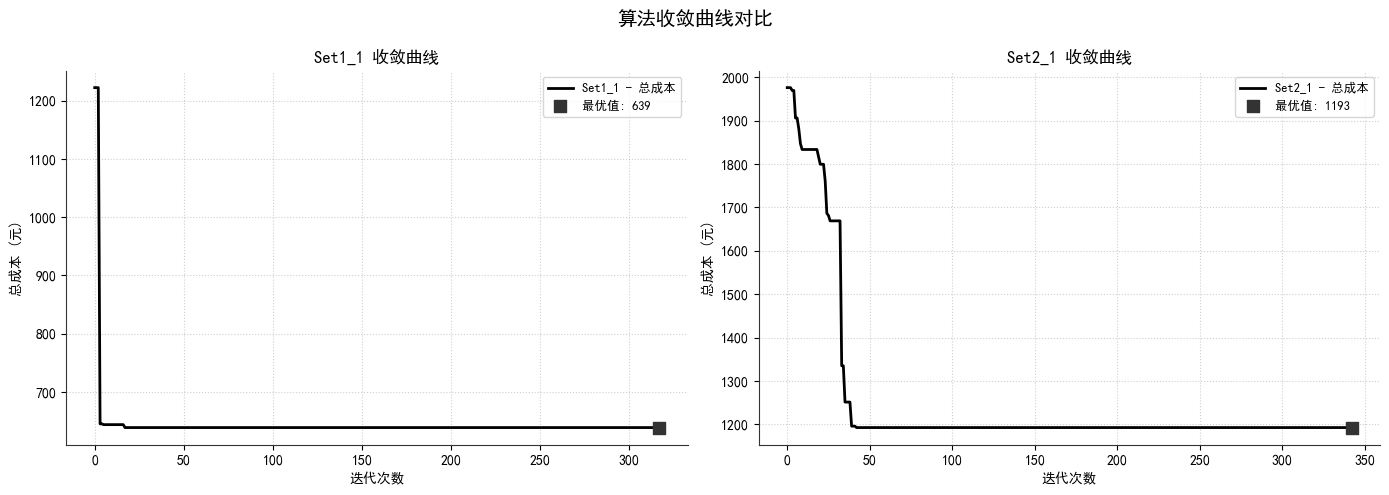


结果汇总

Set1_1:
  最优成本: 639.03
  求解时间: 0.20 秒
  最终迭代次数: 317

Set2_1:
  最优成本: 1192.60
  求解时间: 0.71 秒
  最终迭代次数: 342


In [2]:
# ==================== 收敛图绘制 ====================
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

# 设置中文字体（根据系统调整）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置黑白灰配色方案
colors = ['#000000', '#333333', '#666666', '#999999', '#CCCCCC']
markers = ['s', 'o', '^', 'd', 'v']
line_styles = ['-', '--', '-.', ':']

class CostRecorder:
    """成本记录器，用于记录每次迭代的最优成本变化"""
    def __init__(self):
        self.iterations = []
        self.best_costs = []
        self.current_costs = []
        self.start_time = time.time()
        
    def record(self, iteration, best_cost, current_cost):
        self.iterations.append(iteration)
        self.best_costs.append(best_cost)
        self.current_costs.append(current_cost)
        
    def get_data(self):
        return self.iterations, self.best_costs, self.current_costs

# 修改ImprovedTS_ALNS类，添加记录功能
class ImprovedTS_ALNS_WithRecord(ImprovedTS_ALNS):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.recorder = CostRecorder()
        self.actual_iterations = 0  # 记录实际执行的迭代次数
        
    def search(self):
        """主搜索过程（带记录）"""
        current = initial_solution(self.prob, self.dist)
        current_cost = self.evaluate(current)
        self.best_solution = current
        self.best_cost = current_cost
        
        # 记录初始解
        self.recorder.record(0, self.best_cost, current_cost)

        print("\n=== 初始解 ===")
        for tid, route in current.items():
            print(f"卡车{tid+1}: {route}")
        print(f"初始总成本: {current_cost:.2f}\n")

        no_improve = 0
        
        # 阶段统计
        destroy_scores_seg = [0.0] * len(self.destroy_weights)
        destroy_attempts_seg = [0] * len(self.destroy_weights)
        repair_scores_seg = [0.0] * len(self.repair_weights)
        repair_attempts_seg = [0] * len(self.repair_weights)
        local_scores_seg = [0.0] * len(self.local_weights)
        local_attempts_seg = [0] * len(self.local_weights)

        for self.iter_count in range(self.max_iter):
            # 每100次迭代更新权重
            if self.iter_count > 0 and self.iter_count % self.segment_size == 0:
                self.update_weights()
                destroy_scores_seg = [0.0] * len(self.destroy_weights)
                destroy_attempts_seg = [0] * len(self.destroy_weights)
                repair_scores_seg = [0.0] * len(self.repair_weights)
                repair_attempts_seg = [0] * len(self.repair_weights)
                local_scores_seg = [0.0] * len(self.local_weights)
                local_attempts_seg = [0] * len(self.local_weights)

            # 决定使用大规模破坏-修复还是小范围邻域搜索
            use_large = random.random() < self.large_destroy_prob
            
            if use_large:
                # 大规模破坏-修复
                remove_ratio = random.choice(self.remove_ratios)
                new_sol, destroy_idx, repair_idx, removed, success = self.apply_large_destroy_repair(current, remove_ratio)
                
                if not success or not new_sol:
                    continue
                
                new_cost = self.evaluate(new_sol)
                
                # 更新阶段统计
                if destroy_idx is not None:
                    destroy_attempts_seg[destroy_idx] += 1
                if repair_idx is not None:
                    repair_attempts_seg[repair_idx] += 1
                
                improved = new_cost < current_cost
                is_new_best = new_cost < self.best_cost
                
                if is_new_best:
                    destroy_scores_seg[destroy_idx] += 1.5 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 1.5 if repair_idx is not None else 0
                elif improved:
                    destroy_scores_seg[destroy_idx] += 1.0 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 1.0 if repair_idx is not None else 0
                else:
                    destroy_scores_seg[destroy_idx] += 0.5 if destroy_idx is not None else 0
                    repair_scores_seg[repair_idx] += 0.5 if repair_idx is not None else 0
                
                # 接受准则（模拟退火）
                if new_cost < current_cost:
                    current = new_sol
                    current_cost = new_cost
                    if is_new_best:
                        self.best_solution = new_sol
                        self.best_cost = new_cost
                        no_improve = 0
                    else:
                        no_improve += 1
                else:
                    delta = new_cost - current_cost
                    accept_prob = math.exp(-delta / max(self.temperature, 0.1))
                    if random.random() < accept_prob:
                        current = new_sol
                        current_cost = new_cost
                        no_improve += 1
                    else:
                        no_improve += 1
                
            else:
                # 小范围邻域搜索
                # 生成多个候选解
                candidates = []
                for _ in range(5):
                    new_sol, info, local_idx, success = self.apply_local_operator(current)
                    if success:
                        new_cost = self.evaluate(new_sol)
                        candidates.append((new_cost, new_sol, info, local_idx))
                        local_attempts_seg[local_idx] += 1
                
                if not candidates:
                    continue
                
                candidates.sort(key=lambda x: x[0])
                
                selected = None
                for cost, sol, info, local_idx in candidates:
                    if not self.is_tabu(info):
                        if cost < current_cost:
                            selected = (cost, sol, info, local_idx)
                            break
                        else:
                            delta = cost - current_cost
                            accept_prob = math.exp(-delta / max(self.temperature, 0.1))
                            if random.random() < accept_prob:
                                selected = (cost, sol, info, local_idx)
                                break
                
                if selected is None and candidates:
                    best_candidate = candidates[0]
                    selected = best_candidate
                
                if selected is None:
                    continue
                
                cost, sol, info, local_idx = selected
                
                improved = cost < current_cost
                is_new_best = cost < self.best_cost
                
                if is_new_best:
                    local_scores_seg[local_idx] += 1.5
                elif improved:
                    local_scores_seg[local_idx] += 1.0
                else:
                    local_scores_seg[local_idx] += 0.5
                
                self.add_tabu(info)
                current = sol
                current_cost = cost
                
                if is_new_best:
                    self.best_solution = sol
                    self.best_cost = cost
                    no_improve = 0
                else:
                    no_improve += 1
            
            # 记录成本（只记录实际执行的迭代，用实际迭代次数计数）
            self.actual_iterations += 1
            self.recorder.record(self.actual_iterations, self.best_cost, current_cost)
            
            # 降温
            self.temperature *= self.cooling_rate
            
            # 早停
            if no_improve >= self.patience:
                break
        
        return self.best_solution, self.best_cost, self.recorder


def run_and_record(file_path, instance_name, prob_params, solver_params):
    """运行单个实例并记录结果"""
    print(f"\n{'='*60}")
    print(f"运行实例: {instance_name}")
    print(f"{'='*60}")
    
    # 读取数据
    df = pd.read_excel(file_path)
    
    x_col = df.columns[0]
    y_col = df.columns[1]
    id_col = df.columns[2]
    demand_col = df.columns[3]
    
    nodes_data = []
    for idx, row in df.iterrows():
        node_id = int(row[id_col])
        x = float(row[x_col])
        y = float(row[y_col])
        demand = float(row[demand_col]) if demand_col in df.columns else 0
        nodes_data.append((x, y, demand, node_id))
    
    nodes_data.sort(key=lambda x: x[3])
    nodes = [Node(x, y, demand) for x, y, demand, _ in nodes_data]
    n = len(nodes)
    print(f"节点数量: {n} (配送中心 + {n-1}个客户)")
    
    # 禁飞区定义
    zone1 = Zone([(40, 40), (60, 40), (50, 60)], active_start=0, active_end=24)
    zone2 = Zone([(-70, -20), (-85, -25), (-90, -40), (-75, -45), (-65, -30)], active_start=8, active_end=20)
    zone3 = Zone([(-10, 60), (-30, 65), (-25, 80), (-5, 75)], active_start=12, active_end=16)
    no_fly_zones = [zone1, zone2, zone3]
    
    dist = build_distance_matrix(nodes)
    drone_dist_func = build_drone_distance_function(nodes, no_fly_zones)
    
    truck_feasible = np.ones((n, n), dtype=bool)
    for i in range(n):
        truck_feasible[i, i] = False
    
    total_demand = sum(node.demand for node in nodes[1:])
    estimated_trucks = math.ceil(total_demand / prob_params['truck_capacity'])
    
    prob = Problem(
        nodes=nodes,
        truck_speed=prob_params['truck_speed'],
        drone_speed=prob_params['drone_speed'],
        truck_capacity=prob_params['truck_capacity'],
        drone_capacity=prob_params['drone_capacity'],
        truck_max_dist=prob_params['truck_max_dist'],
        drone_max_dist=prob_params['drone_max_dist'],
        num_trucks=estimated_trucks,
        truck_feasible=truck_feasible,
        no_fly_zones=no_fly_zones
    )
    
    # 创建带记录的求解器
    solver = ImprovedTS_ALNS_WithRecord(
        prob, dist, drone_dist_func,
        max_iter=solver_params['max_iter'],
        tabu_len=solver_params['tabu_len'],
        patience=solver_params['patience'],
        c_truck_km=solver_params['c_truck_km'],
        c_drone_km=solver_params['c_drone_km'],
        c_truck_fixed=solver_params['c_truck_fixed'],
        c_drone_fixed=solver_params['c_drone_fixed'],
        c_wait_drone=solver_params['c_wait_drone'],
        c_wait_truck=solver_params['c_wait_truck'],
        temperature=solver_params['temperature'],
        cooling_rate=solver_params['cooling_rate'],
        large_destroy_prob=solver_params['large_destroy_prob']
    )
    
    start_time = time.time()
    best_sol, best_cost, recorder = solver.search()
    solve_time = time.time() - start_time
    
    print(f"\n{instance_name} 完成!")
    print(f"  最优成本: {best_cost:.2f}")
    print(f"  求解时间: {solve_time:.2f} 秒")
    print(f"  实际迭代次数: {solver.actual_iterations}")
    
    return recorder, best_cost, solve_time, solver.actual_iterations


# ==================== 主程序：运行Set1_1和Set2_1并绘制收敛图 ====================
if __name__ == '__main__':
    import pandas as pd
    import os
    
    # 问题参数配置
    prob_params = {
        'truck_speed': 50,
        'drone_speed': 75,
        'truck_capacity': 1000,
        'drone_capacity': 3,
        'truck_max_dist': 500,
        'drone_max_dist': 30
    }
    
    # 求解器参数配置
    solver_params = {
        'max_iter': 2000,
        'tabu_len': 15,
        'patience': 300,
        'c_truck_km': 1.0,
        'c_drone_km': 0.1,
        'c_truck_fixed': 200,
        'c_drone_fixed': 10,
        'c_wait_drone': 1.0,
        'c_wait_truck': 10.0,
        'temperature': 3000,
        'cooling_rate': 0.98,
        'large_destroy_prob': 0.4
    }
    
    # 文件路径
    base_path = r"C:\Users\yu\Desktop"
    instances = {
        'Set1_1': os.path.join(base_path, 'Set1_1.xlsx'),
        'Set2_1': os.path.join(base_path, 'Set2_1.xlsx')
    }
    
    # 运行实例并记录
    results = {}
    for name, path in instances.items():
        if os.path.exists(path):
            recorder, best_cost, solve_time, actual_iters = run_and_record(path, name, prob_params, solver_params)
            results[name] = {
                'recorder': recorder,
                'best_cost': best_cost,
                'solve_time': solve_time,
                'actual_iterations': actual_iters
            }
        else:
            print(f"文件不存在: {path}")
    
    # ==================== 绘制收敛图 ====================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('算法收敛曲线对比', fontsize=14, fontweight='bold')
    
    # 黑白灰配色
    colors = ['#000000', '#333333', '#666666']
    line_styles = ['-', '--']
    
    for idx, (name, result) in enumerate(results.items()):
        ax = axes[idx]
        recorder = result['recorder']
        iterations = recorder.iterations
        best_costs = recorder.best_costs
        
        # 绘制最优成本收敛曲线
        ax.plot(iterations, best_costs, 
                color=colors[0], 
                linestyle=line_styles[0], 
                linewidth=2,
                label=f'{name} - 总成本')
        
        # 标记最终最优值
        ax.scatter([iterations[-1]], [best_costs[-1]], 
                   color=colors[1], s=80, zorder=5,
                   marker='s', label=f'最优值: {best_costs[-1]:.0f}')
        
        # 设置标题和标签
        ax.set_title(f'{name} 收敛曲线', fontsize=12)
        ax.set_xlabel('迭代次数', fontsize=10)
        ax.set_ylabel('总成本 (元)', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        
        # 设置坐标轴样式
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        

    
    plt.tight_layout()
    

    # 显示图片
    plt.show()
    
    # 打印结果汇总
    print("\n" + "="*60)
    print("结果汇总")
    print("="*60)
    for name, result in results.items():
        print(f"\n{name}:")
        print(f"  最优成本: {result['best_cost']:.2f}")
        print(f"  求解时间: {result['solve_time']:.2f} 秒")
        print(f"  最终迭代次数: {result['actual_iterations']}")